# 03c — Validation qualité du dataset enrichi

Notebook de **contrôle qualité manuel** de `nayaar_knowledge_base.csv`
(brique "Validation manuelle" du chemin critique, voir `Docs/MVP_SCOPE.md`).

Ce notebook ne corrige rien : il **affiche** et **teste**, pour que tu puisses
juger à l'œil si l'enrichissement du notebook 03b est correct avant de
passer aux embeddings.

**Entrée** : `data/processed/nayaar_knowledge_base.csv`

Contenu :
1. Échantillon lisible de 30 parfums (toutes les features)
2. Tests de cohérence automatiques
3. Contrôles ciblés (summer_score le plus haut, winter_score le plus haut, profil)
4. Taux de remplissage de chaque feature
5. Visualisations (scores, familles, profils)

La lisibilité de l'affichage est priorisée sur l'élégance du code.

In [1]:
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CHEMIN_KNOWLEDGE_BASE = "../processed/nayaar_knowledge_base.csv"

sns.set_theme(style="whitegrid")

# Affichage pandas large : on privilégie la lisibilité, pas la compacité
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)


In [2]:
df = pd.read_csv(CHEMIN_KNOWLEDGE_BASE, encoding="utf-8")
df["notes_list"] = df["notes_list"].apply(json.loads)
df["notes_categories"] = df["notes_categories"].apply(json.loads)

# Colonnes texte courtes pour un affichage lisible en tableau
df["notes_texte"] = df["notes_list"].apply(lambda notes: ", ".join(notes))
df["categories_texte"] = df["notes_categories"].apply(lambda cats: ", ".join(cats))

print(f"Parfums chargés : {len(df)}")
df.head(3)


Parfums chargés : 2191


,Name,Brand,Description,Notes,Image URL,notes_manquantes,notes_list,notes_categories,famille,winter_score,spring_score,summer_score,autumn_score,day_score,night_score,profil,concentration,profil_text,notes_texte,categories_texte
0,Tihota Eau de Parfum,Indult,"Rapa Nui for sugar, Tihota is, quite simply, The One. The One that will call...","Vanilla bean, musks",https://static.luckyscent.com/images/products/37401.jpg?width=400&404=produc...,False,"[vanilla bean, musks]","[gourmand, musque]",gourmand,0.70,0.40,0.35,0.65,0.40,0.75,unisex,Eau de Parfum,"Tihota Eau de Parfum par Indult, Eau de Parfum. Famille olfactive : gourmand...","vanilla bean, musks","gourmand, musque"
1,Sola Parfum,Di Ser,A tribute to the expanse of space extending from the sky to the flower and f...,"Lavender, Yuzu, Lemongrass, Magnolia, Geranium, Jasmine, Frankincense, Myrrh",https://static.luckyscent.com/images/products/788011.jpg?width=400&404=produ...,False,"[lavender, yuzu, lemongrass, magnolia, geranium, jasmine, frankincense, myrrh]","[floral, aromatique, oriental_ambre, agrumes]",floral,0.45,0.68,0.56,0.47,0.64,0.53,unisex,Parfum,"Sola Parfum par Di Ser, Parfum. Famille olfactive : floral. Notes : lavender...","lavender, yuzu, lemongrass, magnolia, geranium, jasmine, frankincense, myrrh","floral, aromatique, oriental_ambre, agrumes"
2,Kagiroi Parfum,Di Ser,"An aromatic ode to the ancient beauty of Japan, Kagiroi represents the chang...","Green yuzu, green shikuwasa, sansho seed, coriander, ylang-ylang, shiso, ros...",https://static.luckyscent.com/images/products/788012.jpg?width=400&404=produ...,False,"[green yuzu, green shikuwasa, sansho seed, coriander, ylang-ylang, shiso, ro...","[boise, epice, floral, aromatique]",boise,0.62,0.49,0.39,0.63,0.48,0.71,masculine,Parfum,"Kagiroi Parfum par Di Ser, Parfum. Famille olfactive : boise. Notes : corian...","green yuzu, green shikuwasa, sansho seed, coriander, ylang-ylang, shiso, ros...","boise, epice, floral, aromatique"


## 1. Échantillon lisible de 30 parfums

Un tirage aléatoire (graine fixe pour reproductibilité), avec **toutes les
features générées** dans un tableau unique.

In [3]:
COLONNES_FEATURES = [
    "Name", "Brand", "notes_texte", "categories_texte", "famille",
    "winter_score", "spring_score", "summer_score", "autumn_score",
    "day_score", "night_score", "profil", "concentration",
]

echantillon_30 = df[COLONNES_FEATURES].sample(30, random_state=42).reset_index(drop=True)
echantillon_30


,Name,Brand,notes_texte,categories_texte,famille,winter_score,spring_score,summer_score,autumn_score,day_score,night_score,profil,concentration
0,Siberian Rose Eau de Parfum,Fragrance du Bois,"pink pepper, pear, cinnamon, juniper, tuberose, ylang-ylang, rose, leather, ...","floral, epice, vert, fruite, cuir, boise, oriental_ambre",floral,0.48,0.61,0.48,0.54,0.55,0.60,feminine,Eau de Parfum
1,Gold Watan Eau de Parfum,ANFAS,"cistus, oud, nagarmotha, floral notes, musk, sugar","boise, oriental_ambre, musque, gourmand",boise,0.72,0.38,0.30,0.68,0.38,0.80,unisex,Eau de Parfum
2,Zagorsk Eau de Toilette,Comme des Garcons: Incense,"white incense, pine, pimento berries, violet, cedar, iris, hinoki wood, birc...","floral, boise, vert",floral,0.46,0.68,0.48,0.52,0.60,0.58,feminine,Eau de Toilette
3,Rose de Petra Eau de Parfum,Stephane Humbert Lucas 777,"rose oxide, pomegranate, litchi, bulgarian rose, pepper, cardamom, cumin seeds.","floral, epice, fruite",epice,0.44,0.66,0.56,0.54,0.58,0.58,feminine,Eau de Parfum
4,Monserrat Eau de Parfum,Bruno Fazzolari,"pink grapefruit, green leaves, carrot seed, osmanthus, jasmine, white musk, ...","floral, agrumes, vert, boise, musque",floral,0.42,0.70,0.60,0.48,0.67,0.50,unisex,Eau de Parfum
5,Feminite du Bois Eau de Parfum,Serge Lutens,"ginger, cinnamon, clove, plum, peach, orange blossom, violet, cedar, sandalw...","epice, fruite, floral, boise, gourmand, oriental_ambre",epice,0.55,0.53,0.46,0.61,0.50,0.65,feminine,Eau de Parfum
6,Iridescent Sky Eau de Parfum,Strangers Parfumerie,"pomelo, tea, bergamot, neroli, pineapple, orris, damask rose, vetiver, lemon...","floral, agrumes, fruite, musque, aromatique, boise",floral,0.38,0.69,0.65,0.48,0.66,0.47,unisex,Eau de Parfum
7,Patchouli Eau de Toilette,Mazzolari,"indonesian patchouli, spices, hints of amber, honey","boise, gourmand",gourmand,0.75,0.35,0.25,0.70,0.35,0.80,unisex,Eau de Toilette
8,Black III Parfum Extrait,Widian,"bergamot, spearmint, leather, dry wood, vanilla, moss, patchouli, sandalwood","boise, agrumes, aromatique, cuir, gourmand, vert",boise,0.57,0.49,0.44,0.57,0.51,0.62,unisex,Parfum
9,Single Man Eau de Parfum,Moth and Rabbit,"cardamom, ginger oil, red pepper, winter lemon oil, nutmeg, rose, elemi oil,...","epice, boise, floral, vert, oriental_ambre",epice,0.62,0.49,0.39,0.63,0.47,0.72,unisex,Eau de Parfum


## 2. Tests de cohérence automatiques

Chaque test affiche clairement **ce qui est vérifié**, **combien de lignes
posent problème**, et **des exemples concrets** si problème il y a.

In [4]:
print("=== TEST 1 : tous les scores sont bien dans l'intervalle [0, 1] ===\n")

colonnes_scores = ["winter_score", "spring_score", "summer_score", "autumn_score", "day_score", "night_score"]
scores_hors_bornes = df[(df[colonnes_scores] < 0).any(axis=1) | (df[colonnes_scores] > 1).any(axis=1)]

print(f"Lignes avec un score hors [0, 1] : {len(scores_hors_bornes)} / {len(df)}")
if len(scores_hors_bornes) > 0:
    print(scores_hors_bornes[["Name"] + colonnes_scores])
else:
    print("-> OK, aucun score hors bornes.")


=== TEST 1 : tous les scores sont bien dans l'intervalle [0, 1] ===

Lignes avec un score hors [0, 1] : 0 / 2191
-> OK, aucun score hors bornes.


In [5]:
print("=== TEST 2 : parfums sans AUCUNE note reconnue (features 'neutres par défaut') ===\n")
print("Rappel : quand aucune note du parfum n'est dans le vocabulaire, le notebook 03b")
print("applique un score neutre de 0.5 partout (documenté, pas un 0 silencieux).")
print("On détecte donc ces cas en repérant les 6 scores EXACTEMENT égaux à 0.5.\n")

masque_neutre = (df[colonnes_scores] == 0.5).all(axis=1)
parfums_neutres = df[masque_neutre]

print(f"Parfums entièrement neutres (aucune note reconnue) : {len(parfums_neutres)} / {len(df)} ({100*len(parfums_neutres)/len(df):.1f}%)")
print("\nExemples :")
parfums_neutres[["Name", "Brand", "notes_texte", "famille"]].head(10)


=== TEST 2 : parfums sans AUCUNE note reconnue (features 'neutres par défaut') ===

Rappel : quand aucune note du parfum n'est dans le vocabulaire, le notebook 03b
applique un score neutre de 0.5 partout (documenté, pas un 0 silencieux).
On détecte donc ces cas en repérant les 6 scores EXACTEMENT égaux à 0.5.

Parfums entièrement neutres (aucune note reconnue) : 132 / 2191 (6.0%)

Exemples :


,Name,Brand,notes_texte,famille
59,Tabac Rose Eau de Parfum,BDK Parfums,"pink pepper from madagascar, plum accord, lemon from italy, rose from turkey...",NaN
76,Bell'Antonio Eau de Parfum,Hilde Soliani,tobacco and coffee,NaN
86,Ambre Stone Eau de Parfum,Anthologie de Grands Crus,"ambergris infusion, indonesian patchouli oil, egyptian jasmine absolute late...",NaN
87,Vanille d'Amine Eau de Parfum,Anthologie de Grands Crus,"madagascan vanilla olã©orã©sin, somalian olibanum, madagascan clove bud oil",NaN
88,Bergamote de G. Franco Eau de Parfum,Anthologie de Grands Crus,"italian bergamot oil grand cru, moroccan mimosa absolute, chinese osmanthus ...",NaN
89,Vetiver de Pierre Eau de Parfum,Anthologie de Grands Crus,"haitian vetiver oil special grand cru, venezuelan tonka absolute, ivory coas...",NaN
90,Jasmin de Cherifa Eau de Parfum,Anthologie de Grands Crus,"egyptian jasmine absolute grand cru, egyptian rose absolute centifolia grand...",NaN
103,Lambrosc Eau de Parfum,Hilde Soliani,"sweet red fruits, red wine",NaN
125,Muskara Phero J Eau de Parfum,Fueguia 1833,"musks ""from the pheromone family""",NaN
214,O Hira Eau de Parfum,Stephane Humbert Lucas 777,fossilized amber,NaN


In [6]:
print("=== TEST 3 : familles valides ===\n")

FAMILLES_CONNUES = {
    "agrumes", "floral", "boise", "epice", "oriental_ambre", "aromatique",
    "fruite", "gourmand", "musque", "vert", "aquatique", "cuir",
}

# une famille est valide si elle est vide (aucune note reconnue) OU dans la liste connue
familles_presentes = set(df["famille"].unique())
familles_inattendues = familles_presentes - FAMILLES_CONNUES - {""}
# pandas peut charger les chaines vides comme NaN a la lecture du CSV : on les traite comme vides
familles_inattendues = {f for f in familles_inattendues if pd.notna(f)}

print(f"Familles rencontrées dans le dataset : {sorted(f for f in familles_presentes if pd.notna(f))}")
print(f"Familles inattendues (hors des 12 + vide) : {familles_inattendues if familles_inattendues else 'aucune -> OK'}")

print("\nCohérence famille <-> notes_categories : la famille doit être vide SI ET SEULEMENT SI")
print("notes_categories est vide (pas de note reconnue).")
incoherences = df[(df["famille"].isna() | (df["famille"] == "")) != (df["notes_categories"].apply(len) == 0)]
print(f"Lignes incohérentes : {len(incoherences)} / {len(df)}")
if len(incoherences) > 0:
    incoherences[["Name", "famille", "categories_texte"]]


=== TEST 3 : familles valides ===

Familles rencontrées dans le dataset : ['agrumes', 'aquatique', 'aromatique', 'boise', 'cuir', 'epice', 'floral', 'fruite', 'gourmand', 'musque', 'oriental_ambre', 'vert']
Familles inattendues (hors des 12 + vide) : aucune -> OK

Cohérence famille <-> notes_categories : la famille doit être vide SI ET SEULEMENT SI
notes_categories est vide (pas de note reconnue).
Lignes incohérentes : 0 / 2191


In [7]:
print("=== TEST 4 : profil valide ===\n")

PROFILS_CONNUS = {"masculine", "feminine", "unisex"}
profils_presents = set(df["profil"].unique())
profils_inattendus = profils_presents - PROFILS_CONNUS

print(f"Valeurs de profil rencontrées : {sorted(profils_presents)}")
print(f"Valeurs inattendues : {profils_inattendus if profils_inattendus else 'aucune -> OK'}")


=== TEST 4 : profil valide ===

Valeurs de profil rencontrées : ['feminine', 'masculine', 'unisex']
Valeurs inattendues : aucune -> OK


In [8]:
print("=== TEST 5 : concentration valide ===\n")

CONCENTRATIONS_CONNUES = {
    "Extrait de Parfum", "Eau de Parfum", "Eau de Toilette", "Cologne Absolue",
    "Eau de Cologne", "Eau Fraiche", "Elixir", "Perfume Oil", "Attar",
    "Absolu", "Parfum", "Cologne", "",
}
concentrations_presentes = set(df["concentration"].fillna("").unique())
concentrations_inattendues = concentrations_presentes - CONCENTRATIONS_CONNUES

print(f"Valeurs de concentration rencontrées : {sorted(concentrations_presentes)}")
print(f"Valeurs inattendues : {concentrations_inattendues if concentrations_inattendues else 'aucune -> OK'}")
print(f"\nTaux de non-détection : {(df['concentration'].fillna('') == '').mean()*100:.1f}%")


=== TEST 5 : concentration valide ===

Valeurs de concentration rencontrées : ['', 'Absolu', 'Cologne', 'Cologne Absolue', 'Eau Fraiche', 'Eau de Cologne', 'Eau de Parfum', 'Eau de Toilette', 'Elixir', 'Extrait de Parfum', 'Parfum', 'Perfume Oil']
Valeurs inattendues : aucune -> OK

Taux de non-détection : 5.0%


## 3. Contrôles ciblés

On vérifie "à l'œil" que les scores extrêmes correspondent à une intuition
de parfumerie : les `summer_score` les plus hauts doivent être dominés par
des notes fraîches/agrumées, les `winter_score` les plus hauts par des notes
ambrées/boisées.

In [9]:
print("=== Top 10 summer_score (attendu : dominance agrumes / aromatique / vert) ===\n")

top_ete = df.sort_values("summer_score", ascending=False).head(10)
top_ete[["Name", "summer_score", "famille", "categories_texte", "notes_texte"]]


=== Top 10 summer_score (attendu : dominance agrumes / aromatique / vert) ===



,Name,summer_score,famille,categories_texte,notes_texte
1107,Saint Julep Eau de Parfum,0.90,agrumes,agrumes,"sweet mint, tangerine, southern magnolia, bourbon, grisalva, sugarcube, crus..."
1300,Rose Atlantic Eau de Parfum,0.90,agrumes,agrumes,"bergamot, petals, lemon oil, linden, salt spray rose accord, dune grass, mus..."
1203,Aqua Celestia Eau de Toilette,0.90,agrumes,agrumes,"lime, cool mint mitcham, blackcurrant bud absolute, mimosa absolute, musk ac..."
2161,Amber perfume oil,0.90,agrumes,agrumes,"tunisian amber, blood orange"
1874,Aqua Universalis Forte Eau de Parfum,0.90,agrumes,agrumes,"bergamot, sicilian citron, bouquet of white flowers, absolutes of egyptian j..."
336,Sorriso Eau de Parfum,0.90,agrumes,agrumes,"bitter chocolate, bitter orange, exotic woods"
335,Palermo Eau de Parfum,0.90,agrumes,agrumes,"sicilian bergamot, bigarade, fresh rose absolute, skin musk, ambrette flower"
612,Le Chant de Camargue Eau de Parfum,0.90,agrumes,agrumes,"bergamot, carmargue rice, sandalwood milk"
1137,Falling Into The Sea Eau de Parfum,0.88,agrumes,"agrumes, fruite","lemon, bergamot, grapefruit, lychee, tropical flowers, warm sand"
1501,"Silk, Lace & Chocolate Eau de Parfum",0.85,fruite,"fruite, agrumes","cocoa absolute, strawberry, bergamot"


In [10]:
print("=== Top 10 winter_score (attendu : dominance oriental_ambre / boise / cuir / gourmand) ===\n")

top_hiver = df.sort_values("winter_score", ascending=False).head(10)
top_hiver[["Name", "winter_score", "famille", "categories_texte", "notes_texte"]]


=== Top 10 winter_score (attendu : dominance oriental_ambre / boise / cuir / gourmand) ===



,Name,winter_score,famille,categories_texte,notes_texte
444,Black Ambergris Parfum Extrait,0.83,oriental_ambre,"oriental_ambre, gourmand","dark chocolate, incense, black ambergris, resins, balsam"
656,Serpentine Eau de Toilette,0.80,oriental_ambre,oriental_ambre,"grass, leaves, pollen (galbanum, iris leaf), oxygen (aldehyde, ozone), aspha..."
1445,Amber Rose Eau de Parfum,0.80,oriental_ambre,oriental_ambre,"may rose, dulce de leche, white amber"
2148,Silk perfume oil,0.80,oriental_ambre,"oriental_ambre, gourmand","white amber, vanilla, marine notes"
682,Dark Eau de Parfum,0.80,gourmand,"gourmand, epice","cocoa, dark chocolate, cinnamon, hazelnut, vanilla"
1356,Bello Rabelo Eau de Parfum,0.80,oriental_ambre,"oriental_ambre, gourmand","port accord, dried fruits, balm, everlasting flower, cistus, amber, wood, be..."
95,Avatar Eau de Parfum,0.80,gourmand,gourmand,"caramel, sugar, milk, biscuits"
1433,Don Eau de Parfum,0.80,gourmand,gourmand,"gunpowder, money, cuban tobacco, whiskey, molasses"
568,Not A Perfume Superdose Eau de Parfum,0.80,oriental_ambre,oriental_ambre,cetalox
1606,Calling all Angels Eau de Parfum,0.80,oriental_ambre,"oriental_ambre, gourmand","incense, labdanum, vanilla, honey, amber, precious woods, opoponax, elemi re..."


In [11]:
print("=== Cohérence famille dominante des Top 10 été / hiver ===\n")

print("Familles des 10 parfums au summer_score le plus haut :")
print(top_ete["famille"].value_counts())

print("\nFamilles des 10 parfums au winter_score le plus haut :")
print(top_hiver["famille"].value_counts())


=== Cohérence famille dominante des Top 10 été / hiver ===

Familles des 10 parfums au summer_score le plus haut :
famille
agrumes    9
fruite     1
Name: count, dtype: int64

Familles des 10 parfums au winter_score le plus haut :
famille
oriental_ambre    7
gourmand          3
Name: count, dtype: int64


In [12]:
print("=== Contrôle ciblé : profil ===\n")
print("Pas de score numérique de profil exporté (seulement la catégorie finale) :")
print("on vérifie donc la cohérence par la répartition des familles au sein de chaque profil.")
print("Attendu : 'masculine' plutôt boisé/cuir/épicé, 'feminine' plutôt floral/fruité, 'unisex' plus mélangé.\n")

for profil in ["masculine", "feminine", "unisex"]:
    sous_ensemble = df[df["profil"] == profil]
    print(f"--- profil = {profil} ({len(sous_ensemble)} parfums) ---")
    print(sous_ensemble["famille"].value_counts(normalize=True).round(2).head(5))
    print()


=== Contrôle ciblé : profil ===

Pas de score numérique de profil exporté (seulement la catégorie finale) :
on vérifie donc la cohérence par la répartition des familles au sein de chaque profil.
Attendu : 'masculine' plutôt boisé/cuir/épicé, 'feminine' plutôt floral/fruité, 'unisex' plus mélangé.

--- profil = masculine (315 parfums) ---
famille
boise             0.37
oriental_ambre    0.17
epice             0.12
floral            0.11
cuir              0.10
Name: proportion, dtype: float64

--- profil = feminine (739 parfums) ---
famille
floral            0.56
gourmand          0.20
oriental_ambre    0.12
fruite            0.07
epice             0.04
Name: proportion, dtype: float64

--- profil = unisex (1137 parfums) ---
famille
oriental_ambre    0.26
boise             0.15
epice             0.15
floral            0.14
agrumes           0.10
Name: proportion, dtype: float64



In [13]:
print("=== 5 exemples par profil (à juger à l'œil) ===\n")

for profil in ["masculine", "feminine", "unisex"]:
    print(f"--- {profil} ---")
    exemples = df[df["profil"] == profil][["Name", "famille", "categories_texte"]].sample(
        min(5, (df["profil"] == profil).sum()), random_state=1
    )
    print(exemples.to_string(index=False))
    print()


=== 5 exemples par profil (à juger à l'œil) ===

--- masculine ---
                                 Name  famille                                     categories_texte
            Gold Knight Eau de Parfum gourmand                      agrumes, epice, boise, gourmand
              Ummagumma Eau de Parfum gourmand gourmand, cuir, oriental_ambre, boise, epice, floral
        Oud Stars - Gao Eau de Parfum    boise                                boise, oriental_ambre
Much Ado About the Duke Eau de Parfum     cuir                        epice, floral, gourmand, cuir
       Cedar Woodpecker Eau de Parfum   floral                                        boise, floral

--- feminine ---
                                Name        famille                                categories_texte
     Tubereuse Couture Eau de Parfum         floral                                floral, gourmand
Rakugan (Sugar Sweets) Eau de Parfum         fruite fruite, floral, gourmand, oriental_ambre, boise
    Calling all

## 4. Taux de remplissage de chaque feature

In [14]:
print("=== Taux de remplissage ===\n")
print("Distinction importante : les scores sont TOUJOURS 'remplis' techniquement")
print("(valeur neutre 0.5 par défaut), donc on affiche aussi le taux basé sur")
print("au moins une note reconnue, plus honnête sur la vraie qualité du signal.\n")

au_moins_une_note = df["notes_list"].apply(len) > 0
au_moins_une_note_reconnue = df["notes_categories"].apply(len) > 0

recapitulatif = pd.DataFrame({
    "colonne": [
        "notes_list (au moins 1 note brute)",
        "notes_categories (au moins 1 note reconnue)",
        "famille (non vide)",
        "winter/spring/summer/autumn_score (valeur réelle, pas le défaut 0.5)",
        "day/night_score (valeur réelle, pas le défaut 0.5)",
        "profil (non vide, toujours rempli)",
        "concentration (détectée, non vide)",
        "profil_text (non vide, toujours rempli)",
    ],
    "taux_de_remplissage_pct": [
        round(au_moins_une_note.mean() * 100, 1),
        round(au_moins_une_note_reconnue.mean() * 100, 1),
        round((df["famille"].fillna("") != "").mean() * 100, 1),
        round(au_moins_une_note_reconnue.mean() * 100, 1),
        round(au_moins_une_note_reconnue.mean() * 100, 1),
        round((df["profil"].fillna("") != "").mean() * 100, 1),
        round((df["concentration"].fillna("") != "").mean() * 100, 1),
        round((df["profil_text"].fillna("") != "").mean() * 100, 1),
    ],
})
recapitulatif


=== Taux de remplissage ===

Distinction importante : les scores sont TOUJOURS 'remplis' techniquement
(valeur neutre 0.5 par défaut), donc on affiche aussi le taux basé sur
au moins une note reconnue, plus honnête sur la vraie qualité du signal.



,colonne,taux_de_remplissage_pct
0,notes_list (au moins 1 note brute),96.3
1,notes_categories (au moins 1 note reconnue),94.0
2,famille (non vide),94.0
3,"winter/spring/summer/autumn_score (valeur réelle, pas le défaut 0.5)",94.0
4,"day/night_score (valeur réelle, pas le défaut 0.5)",94.0
5,"profil (non vide, toujours rempli)",100.0
6,"concentration (détectée, non vide)",95.0
7,"profil_text (non vide, toujours rempli)",100.0


## 5. Visualisations

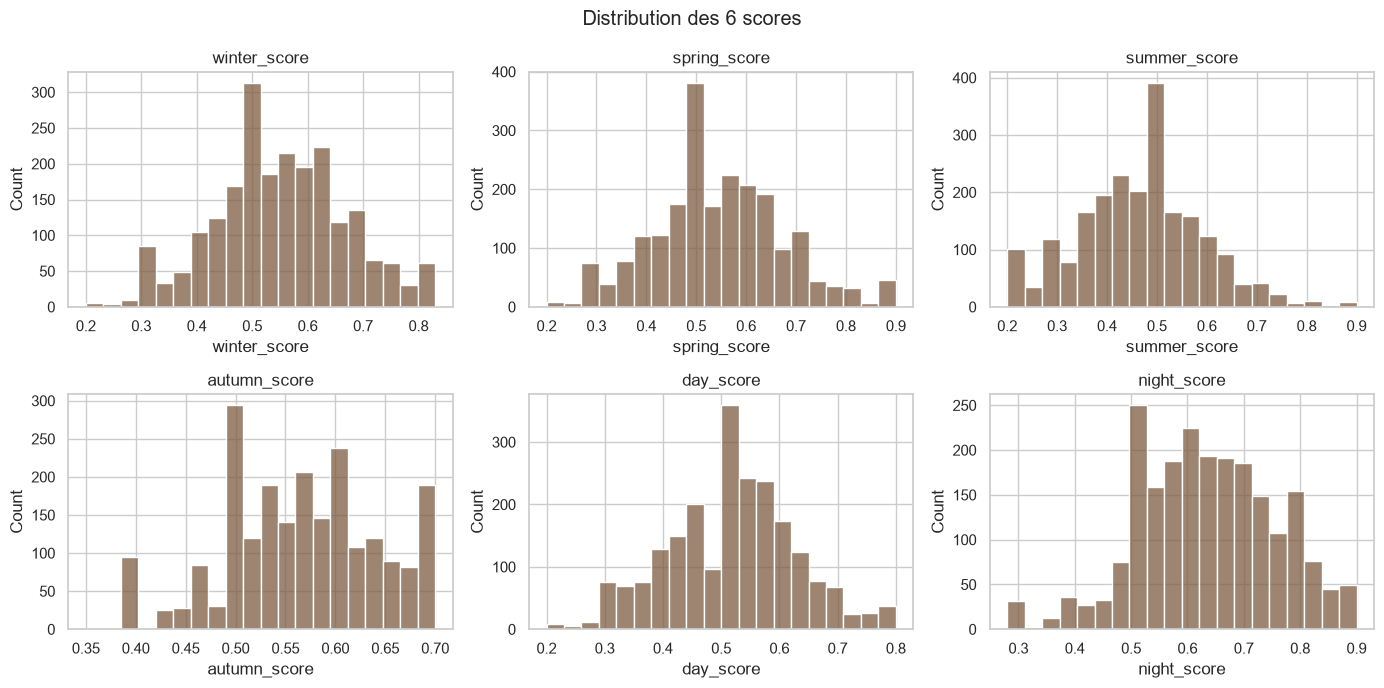

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, colonne in zip(axes.flat, colonnes_scores):
    sns.histplot(df[colonne], bins=20, ax=ax, color="#7c5c42")
    ax.set_title(colonne)
plt.suptitle("Distribution des 6 scores")
plt.tight_layout()
plt.show()


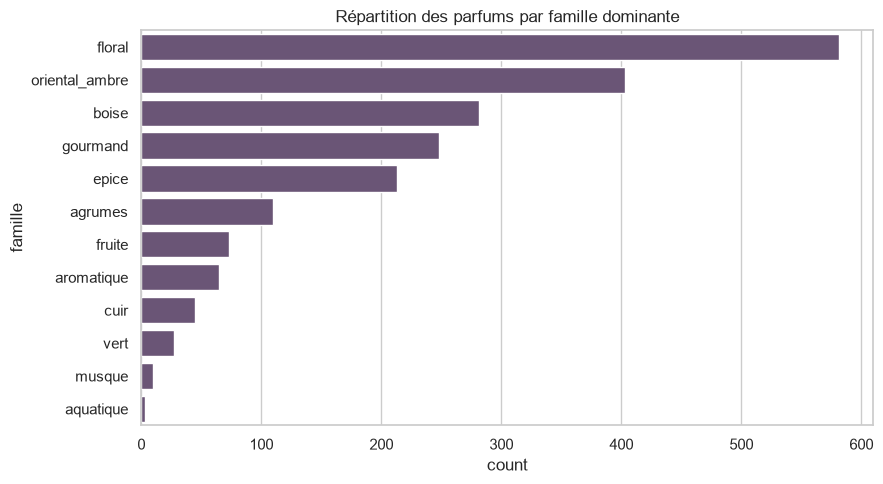

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ordre = df["famille"].replace("", "(aucune)").value_counts().index
sns.countplot(y=df["famille"].replace("", "(aucune)"), order=ordre, ax=ax, color="#6b4f7c")
ax.set_title("Répartition des parfums par famille dominante")
plt.tight_layout()
plt.show()


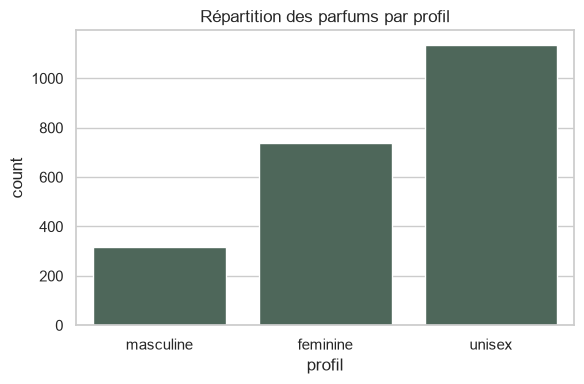

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=df["profil"], order=["masculine", "feminine", "unisex"], ax=ax, color="#4a6b5a")
ax.set_title("Répartition des parfums par profil")
plt.tight_layout()
plt.show()
